# Disease Outbreak Early Warning System

## Notebook 03: Missing Data Assessment and Stationarity Testing

### Purpose

Before forecasting disease incidence, it is important to assess data quality and determine whether the time series satisfies the assumptions required for statistical forecasting models.

### Objectives

* Identify missing values
* Handle missing observations
* Examine temporal stability
* Compute rolling statistics
* Conduct stationarity testing using the Augmented Dickey-Fuller (ADF) test

### Expected Outcome

A cleaned and statistically validated time series ready for forecasting and outbreak detection.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from statsmodels.tsa.stattools import adfuller

pd.set_option("display.max_columns", None)

os.makedirs("images", exist_ok=True)

print("Libraries loaded successfully.")

Libraries loaded successfully.


## Loading and Integrating the Dataset

The dengue surveillance dataset is reconstructed by combining environmental features with weekly disease case counts.


In [3]:
features = pd.read_csv(
    "/content/dengue_features_train.csv"
)

labels = pd.read_csv(
    "/content/dengue_labels_train.csv"
)

dengue_df = pd.merge(
    features,
    labels,
    on=[
        "city",
        "year",
        "weekofyear"
    ]
)

print(dengue_df.shape)

(1456, 25)


## Missing Value Assessment

Environmental monitoring systems frequently contain missing observations. Understanding missingness is critical before model development.


In [4]:
missing_values = (
    dengue_df
    .isnull()
    .sum()
    .sort_values(
        ascending=False
    )
)

missing_values[
    missing_values > 0
]

,0
ndvi_ne,194
ndvi_nw,52
station_avg_temp_c,43
station_diur_temp_rng_c,43
ndvi_se,22
ndvi_sw,22
station_precip_mm,22
station_max_temp_c,20
station_min_temp_c,14
precipitation_amt_mm,13


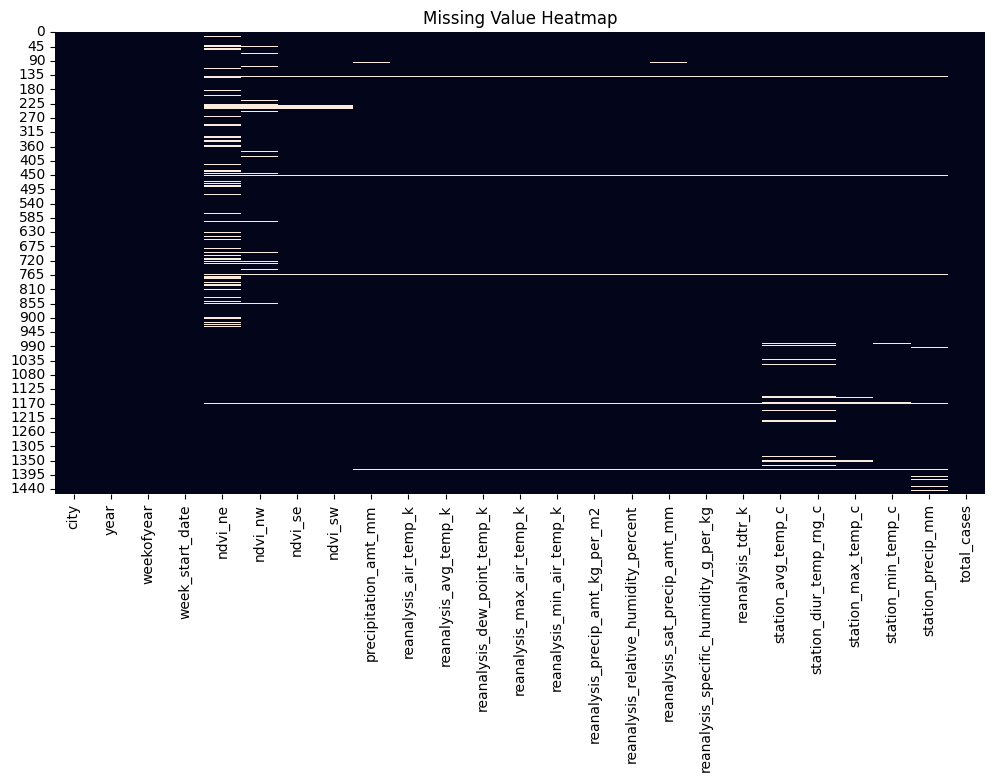

In [5]:
plt.figure(figsize=(12,6))

sns.heatmap(
    dengue_df.isnull(),
    cbar=False
)

plt.title(
    "Missing Value Heatmap"
)

plt.savefig(
    "images/missing_values_heatmap.png",
    bbox_inches="tight"
)

plt.show()

## Missing Value Imputation

Missing environmental observations are replaced using column medians to preserve the overall distribution of the data while minimizing distortion.


In [6]:
numeric_columns = dengue_df.select_dtypes(
    include=np.number
).columns

for column in numeric_columns:
    dengue_df[column] = (
        dengue_df[column]
        .fillna(
            dengue_df[column].median()
        )
    )

print(
    dengue_df.isnull().sum().sum()
)

0


## Creating a Time Series

Weekly dengue case counts are aggregated into a single chronological series for stationarity analysis.


In [7]:
dengue_df["week_start_date"] = pd.to_datetime(
    dengue_df["week_start_date"]
)

time_series = (
    dengue_df
    .groupby("week_start_date")
    ["total_cases"]
    .sum()
)

time_series.head()

,total_cases
week_start_date,
1990-04-30,4
1990-05-07,5
1990-05-14,4
1990-05-21,3
1990-05-28,6


## Rolling Statistics

Rolling averages and rolling standard deviations help visualize changes in the mean and variance of the series over time.


In [8]:
rolling_mean = (
    time_series
    .rolling(window=12)
    .mean()
)

rolling_std = (
    time_series
    .rolling(window=12)
    .std()
)

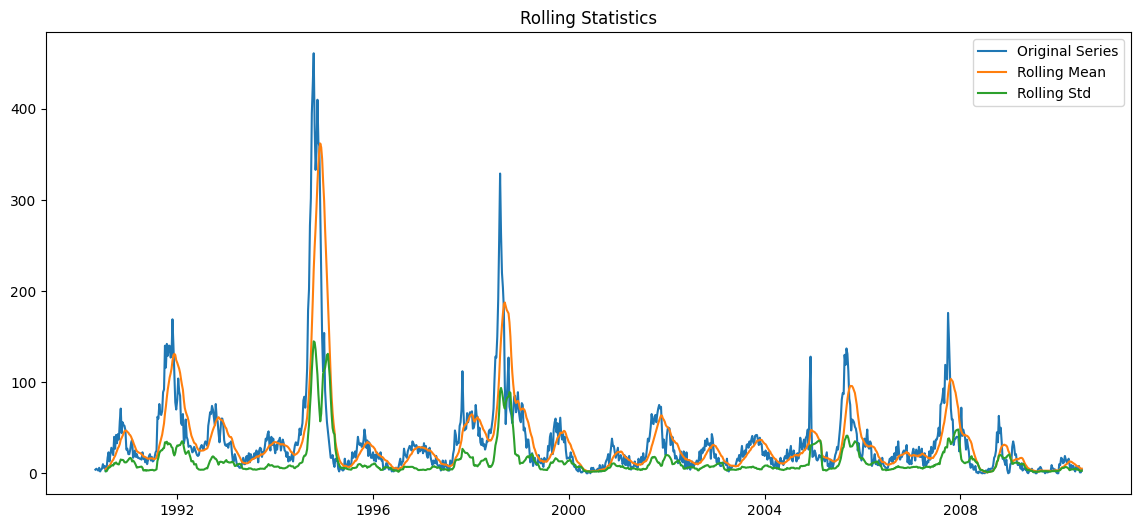

In [9]:
plt.figure(figsize=(14,6))

plt.plot(
    time_series,
    label="Original Series"
)

plt.plot(
    rolling_mean,
    label="Rolling Mean"
)

plt.plot(
    rolling_std,
    label="Rolling Std"
)

plt.legend()

plt.title(
    "Rolling Statistics"
)

plt.savefig(
    "images/rolling_statistics.png",
    bbox_inches="tight"
)

plt.show()

## Augmented Dickey-Fuller Test

The Augmented Dickey-Fuller test evaluates whether the time series is stationary.

A p-value below 0.05 generally indicates stationarity.


In [11]:
adf_result = adfuller(
    time_series
)

print(
    "ADF Statistic:",
    adf_result[0]
)

print(
    "P-Value:",
    adf_result[1]
)

ADF Statistic: -5.939753993142539
P-Value: 2.2757185025854927e-07


In [12]:
if adf_result[1] < 0.05:
    print(
        "The series appears stationary."
    )
else:
    print(
        "The series appears non-stationary."
    )

The series appears stationary.


## Findings

The results of the stationarity analysis provide important guidance for selecting appropriate forecasting models.

If the series is non-stationary, transformations such as differencing may be required before model fitting.
